# Task 1 (Easy): BERT Baseline for Music Tag Understanding

**Course:** Neural Networks (CSE425 / EEE474 / CSE715)
**Dataset:** [google/MusicCaps](https://huggingface.co/datasets/google/MusicCaps) (5,521 clips, text-only columns used — no audio download needed)

This notebook implements **Task 1** from the project spec: a BERT-based multi-label
classifier that predicts music tags/aspects directly from the free-text MusicCaps
**caption**, with no graph structure involved (that's Task 2/3).

Model: `t = BERT_CLS(X_text)`, `y_hat_k = sigmoid(w_k^T t + b_k)`, trained with per-tag
binary cross-entropy summed/averaged over the top-K most frequent aspect tags.

**Pipeline**
1. Load `google/MusicCaps` (text columns only)
2. Parse `aspect_list` into individual tags, build a top-50 tag vocabulary
3. Turn each clip's aspects into a multi-label target vector
4. Fine-tune `distilbert-base-uncased` (swap to `bert-base-uncased` if you want the full model) on `caption -> tags`
5. Track Macro-F1 / Micro-F1 per epoch, plot curves
6. Show 5 example predictions
7. (Optional) Visualize last-layer CLS attention for one example


In [1]:
# If running in Colab / a fresh environment, install dependencies.
# (Skip this cell if these are already installed in your environment.)
!pip install -q transformers datasets torch scikit-learn matplotlib pandas


In [2]:
import ast
import random
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 1. Load the MusicCaps dataset

The dataset only has a single `train` split (5,521 rows). We only need the
`caption` and `aspect_list` text columns for Task 1 — no audio download required.

In [3]:
raw = load_dataset("google/MusicCaps")
print(raw)

df = raw["train"].to_pandas()
print("Rows:", len(df))
print("Columns:", list(df.columns))
df[["caption", "aspect_list"]].head()


README.md:   0%|          | 0.00/5.06k [00:00<?, ?B/s]

musiccaps-public.csv: reconstructing file:   0%|          |  0.00B / 2.94MB            

musiccaps-public.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5521 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['ytid', 'start_s', 'end_s', 'audioset_positive_labels', 'aspect_list', 'caption', 'author_id', 'is_balanced_subset', 'is_audioset_eval'],
        num_rows: 5521
    })
})
Rows: 5521
Columns: ['ytid', 'start_s', 'end_s', 'audioset_positive_labels', 'aspect_list', 'caption', 'author_id', 'is_balanced_subset', 'is_audioset_eval']


,caption,aspect_list
0,The low quality recording features a ballad so...,"['low quality', 'sustained strings melody', 's..."
1,This song features an electric guitar as the m...,"['guitar song', 'piano backing', 'simple percu..."
2,a male voice is singing a melody with changing...,"['amateur recording', 'finger snipping', 'male..."
3,This song contains digital drums playing a sim...,"['backing track', 'jazzy', 'digital drums', 'p..."
4,This song features a rubber instrument being p...,"['rubab instrument', 'repetitive melody on dif..."


## 2. Parse `aspect_list` and build a top-K tag vocabulary

`aspect_list` is stored as the *string* form of a Python list, e.g.
`"['low quality', 'sustained strings melody', 'soulful', 'ballad']"`. We parse it
with `ast.literal_eval`, normalize casing/whitespace, then keep only the
**top 50 most frequent** tags as our label vocabulary (mirrors the MagnaTagATune
"top-50 tags" proxy task described in the project spec).

In [4]:
def parse_aspects(aspect_str):
    try:
        aspects = ast.literal_eval(aspect_str)
    except (ValueError, SyntaxError):
        aspects = [a.strip() for a in str(aspect_str).split(",")]
    return [a.strip().lower() for a in aspects if a.strip()]


df["aspects"] = df["aspect_list"].apply(parse_aspects)
df[["caption", "aspects"]].head()


,caption,aspects
0,The low quality recording features a ballad so...,"[low quality, sustained strings melody, soft f..."
1,This song features an electric guitar as the m...,"[guitar song, piano backing, simple percussion..."
2,a male voice is singing a melody with changing...,"[amateur recording, finger snipping, male mid ..."
3,This song contains digital drums playing a sim...,"[backing track, jazzy, digital drums, piano, e..."
4,This song features a rubber instrument being p...,"[rubab instrument, repetitive melody on differ..."


In [5]:
TOP_K = 50

tag_counter = Counter()
for aspects in df["aspects"]:
    tag_counter.update(aspects)

top_tags = [tag for tag, _ in tag_counter.most_common(TOP_K)]
tag_to_idx = {tag: i for i, tag in enumerate(top_tags)}

print(f"Top {TOP_K} tags:")
for tag, count in tag_counter.most_common(TOP_K):
    print(f"  {tag:35s} {count}")


Top 50 tags:
  low quality                         1220
  instrumental                        908
  emotional                           636
  noisy                               628
  passionate                          610
  medium tempo                        608
  energetic                           599
  amateur recording                   518
  live performance                    477
  slow tempo                          476
  acoustic drums                      394
  fast tempo                          383
  mono                                358
  groovy                              321
  bass guitar                         297
  electric guitar                     297
  acoustic guitar                     292
  instrumental music                  260
  uptempo                             247
  piano                               240
  punchy kick                         239
  poor audio quality                  236
  punchy snare                        235
  groovy bass       

## 3. Build multi-label target vectors

In [6]:
def build_label_vector(aspects, tag_to_idx):
    vec = np.zeros(len(tag_to_idx), dtype=np.float32)
    for a in aspects:
        if a in tag_to_idx:
            vec[tag_to_idx[a]] = 1.0
    return vec

df["labels"] = df["aspects"].apply(lambda a: build_label_vector(a, tag_to_idx))

# Drop any rows with an empty caption (shouldn't be any, but just in case)
df = df[df["caption"].str.len() > 0].reset_index(drop=True)
print("Final dataset size:", len(df))

has_label = df["labels"].apply(lambda v: v.sum() > 0).mean()
print(f"Fraction of clips with >=1 of the top-{TOP_K} tags: {has_label:.2%}")
print(f"Average tags-per-clip (within top-{TOP_K}): {df['labels'].apply(lambda v: v.sum()).mean():.2f}")


Final dataset size: 5521
Fraction of clips with >=1 of the top-50 tags: 90.47%
Average tags-per-clip (within top-50): 2.80


In [7]:
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED)

print(f"Train: {len(train_df)}   Val: {len(val_df)}   Test: {len(test_df)}")


Train: 3864   Val: 828   Test: 829


## 4. Tokenizer + PyTorch Dataset

In [8]:
MODEL_NAME = "distilbert-base-uncased"  # swap to "bert-base-uncased" for the full model
MAX_LEN = 128
BATCH_SIZE = 16

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class MusicTagDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=128):
        self.captions = dataframe["caption"].tolist()
        self.labels = np.stack(dataframe["labels"].values)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.captions)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.captions[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        item = {"input_ids": enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0)}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float32)
        return item


train_ds = MusicTagDataset(train_df, tokenizer, MAX_LEN)
val_ds = MusicTagDataset(val_df, tokenizer, MAX_LEN)
test_ds = MusicTagDataset(test_df, tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

print(f"Batches -> train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Batches -> train: 242  val: 52  test: 52


## 5. Model: `t = BERT_CLS(X_text)`,  `y_hat = sigmoid(W t + b)`

In [16]:
class BERTTagClassifier(nn.Module):
    """Task 1 model from the project spec:
    t = BERT_CLS(X_text);  y_hat_k = sigmoid(w_k^T t + b_k)
    """

    def __init__(self, model_name, num_labels, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name, attn_implementation="eager")
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask, output_attentions=False):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=output_attentions,
        )
        cls_repr = outputs.last_hidden_state[:, 0, :]  # CLS token embedding = t
        logits = self.classifier(self.dropout(cls_repr))
        if output_attentions:
            return logits, outputs.attentions
        return logits


model = BERTTagClassifier(MODEL_NAME, num_labels=TOP_K).to(device)
sum(p.numel() for p in model.parameters() if p.requires_grad)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


66401330

## 6. Training loop (BCE loss, Macro-F1 / Micro-F1 per epoch)

In [10]:
EPOCHS = 5
LR = 2e-5

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
)
criterion = nn.BCEWithLogitsLoss()


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        if train:
            optimizer.zero_grad()
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
        else:
            with torch.no_grad():
                logits = model(input_ids, attention_mask)
                loss = criterion(logits, labels)

        total_loss += loss.item() * input_ids.size(0)
        preds = (torch.sigmoid(logits) > 0.5).float().detach().cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    micro_f1 = f1_score(all_labels, all_preds, average="micro", zero_division=0)
    return avg_loss, macro_f1, micro_f1


history = {"train_loss": [], "val_loss": [],
           "train_macro_f1": [], "val_macro_f1": [],
           "train_micro_f1": [], "val_micro_f1": []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_macro, train_micro = run_epoch(train_loader, train=True)
    val_loss, val_macro, val_micro = run_epoch(val_loader, train=False)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_macro_f1"].append(train_macro)
    history["val_macro_f1"].append(val_macro)
    history["train_micro_f1"].append(train_micro)
    history["val_micro_f1"].append(val_micro)

    print(f"Epoch {epoch}/{EPOCHS} | "
          f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
          f"train_macroF1={train_macro:.4f} val_macroF1={val_macro:.4f} | "
          f"train_microF1={train_micro:.4f} val_microF1={val_micro:.4f}")


Epoch 1/5 | train_loss=0.3476 val_loss=0.2100 | train_macroF1=0.0513 val_macroF1=0.0248 | train_microF1=0.0857 val_microF1=0.1451
Epoch 2/5 | train_loss=0.1867 val_loss=0.1653 | train_macroF1=0.0583 val_macroF1=0.1442 | train_microF1=0.2183 val_microF1=0.3407
Epoch 3/5 | train_loss=0.1553 val_loss=0.1454 | train_macroF1=0.1616 val_macroF1=0.2126 | train_microF1=0.3734 val_microF1=0.4263
Epoch 4/5 | train_loss=0.1407 val_loss=0.1366 | train_macroF1=0.2269 val_macroF1=0.2828 | train_microF1=0.4586 val_microF1=0.5140
Epoch 5/5 | train_loss=0.1339 val_loss=0.1333 | train_macroF1=0.2539 val_macroF1=0.2853 | train_microF1=0.4943 val_microF1=0.5213


## 7. Macro-F1 / Micro-F1 curves vs. epoch (deliverable)

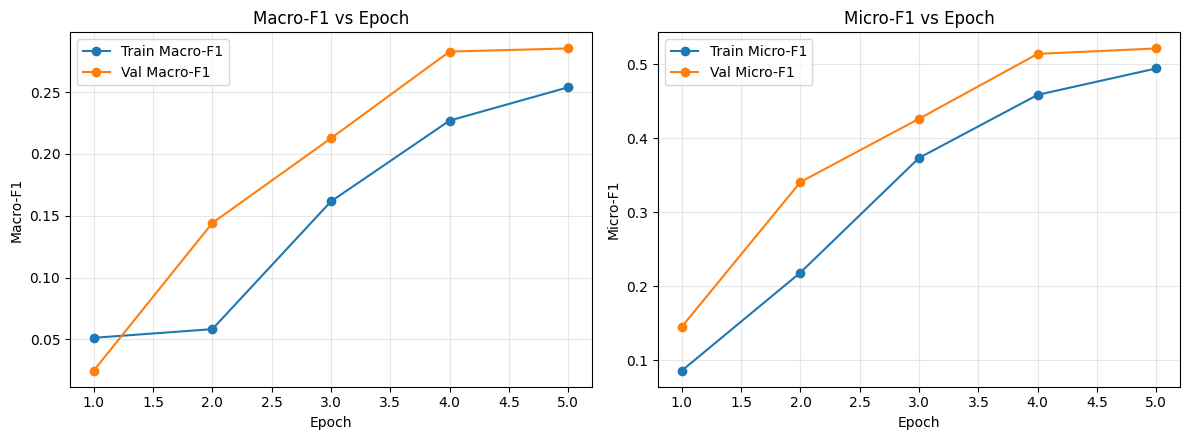

In [11]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(epochs_range, history["train_macro_f1"], marker="o", label="Train Macro-F1")
axes[0].plot(epochs_range, history["val_macro_f1"], marker="o", label="Val Macro-F1")
axes[0].set_title("Macro-F1 vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Macro-F1")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_micro_f1"], marker="o", label="Train Micro-F1")
axes[1].plot(epochs_range, history["val_micro_f1"], marker="o", label="Val Micro-F1")
axes[1].set_title("Micro-F1 vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Micro-F1")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("task1_f1_curves.png", dpi=150)
plt.show()


In [12]:
test_loss, test_macro, test_micro = run_epoch(test_loader, train=False)
print(f"TEST  | loss={test_loss:.4f}  Macro-F1={test_macro:.4f}  Micro-F1={test_micro:.4f}")


TEST  | loss=0.1305  Macro-F1=0.2828  Micro-F1=0.5275


## 8. Five example predictions (deliverable)

In [13]:
model.eval()
sample_df = test_df.sample(n=5, random_state=SEED).reset_index(drop=True)

for i, row in sample_df.iterrows():
    enc = tokenizer(row["caption"], truncation=True, padding="max_length",
                     max_length=MAX_LEN, return_tensors="pt")
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        logits = model(enc["input_ids"], enc["attention_mask"])
        probs = torch.sigmoid(logits).cpu().numpy()[0]

    top5_idx = probs.argsort()[::-1][:5]
    predicted_tags = [(top_tags[j], round(float(probs[j]), 3)) for j in top5_idx]
    true_tags = [top_tags[j] for j in range(TOP_K) if row["labels"][j] == 1.0]

    print(f"\nExample {i + 1}")
    print("Caption:", row["caption"][:200], "...")
    print("Ground-truth top-tags present:", true_tags if true_tags else "(none in top-50)")
    print("Top-5 predicted tags:", predicted_tags)



Example 1
Caption: The low quality recording features an electro house song that consists of punchy "4 on the floor" kick pattern, claps, funky electric guitar melody, groovy synth keys, groovy bass that glues everythin ...
Ground-truth top-tags present: ['low quality', 'energetic', 'mono', 'groovy bass', 'exciting', 'fun']
Top-5 predicted tags: [('low quality', 0.793), ('energetic', 0.778), ('punchy kick', 0.404), ('punchy snare', 0.388), ('groovy bass', 0.316)]

Example 2
Caption: The song is an instrumental. The song is medium with a DJ creating scratchy tones by scratching vinyl on a turntable. The DJ creates an eerie and syncopated rhythm. The audio is bad quality. ...
Ground-truth top-tags present: ['passionate', 'live performance', 'instrumental music', 'exciting']
Top-5 predicted tags: [('medium tempo', 0.581), ('instrumental music', 0.55), ('poor audio quality', 0.286), ('passionate', 0.214), ('emotional', 0.211)]

Example 3
Caption: This is an Indian classical music piece. T

## 9. (Optional) Attention visualization for one example

Shows how much the last-layer `[CLS]` token attends to each input token,
averaged over attention heads.

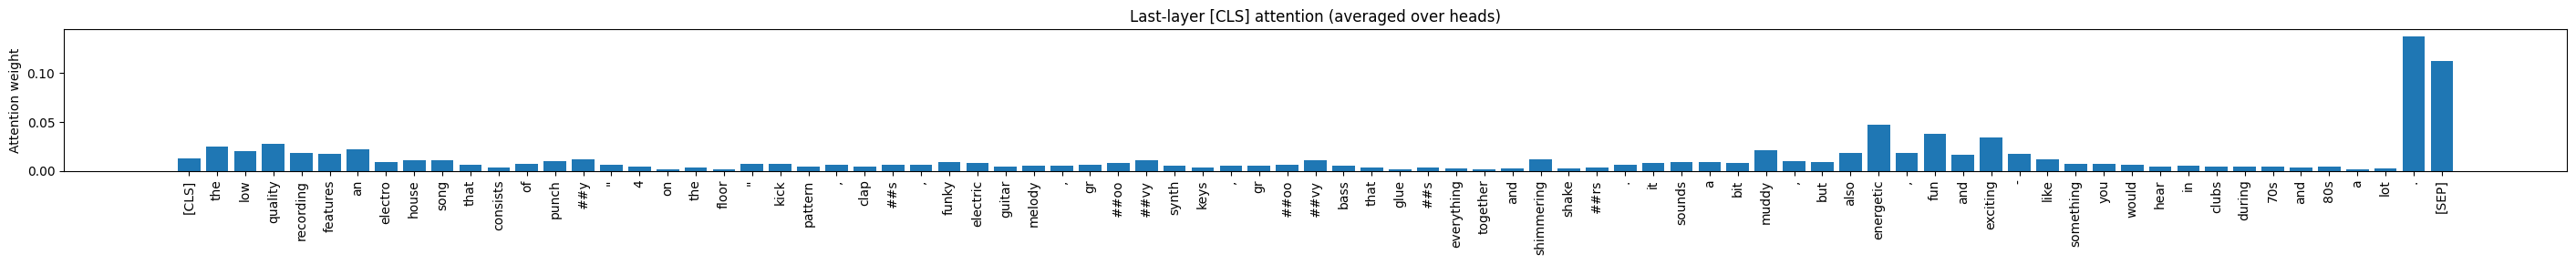

In [18]:
example_caption = sample_df.iloc[0]["caption"]
enc = tokenizer(example_caption, truncation=True, max_length=MAX_LEN, return_tensors="pt")
enc = {k: v.to(device) for k, v in enc.items()}

model.eval()
with torch.no_grad():
    _, attentions = model(enc["input_ids"], enc["attention_mask"], output_attentions=True)

# attentions: tuple(num_layers) of [batch, num_heads, seq_len, seq_len]
last_layer_attn = attentions[-1][0]                          # [num_heads, seq_len, seq_len]
cls_attn = last_layer_attn[:, 0, :].mean(0).cpu().numpy()    # avg over heads, CLS row

tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])

plt.figure(figsize=(max(8, len(tokens) * 0.35), 3))
plt.bar(range(len(tokens)), cls_attn)
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.title("Last-layer [CLS] attention (averaged over heads)")
plt.ylabel("Attention weight")
plt.tight_layout()
plt.savefig("task1_attention_example.png", dpi=150)
plt.show()


In [15]:
torch.save(model.state_dict(), "task1_bert_temp.pt")

In [17]:
model = BERTTagClassifier(MODEL_NAME, num_labels=TOP_K).to(device)
model.load_state_dict(torch.load("task1_bert_temp.pt"))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<All keys matched successfully>

## 10. Save model + tag vocabulary

In [19]:
import json as json_lib

torch.save(model.state_dict(), "task1_bert_tag_classifier.pt")
with open("task1_top_tags.json", "w") as f:
    json_lib.dump(top_tags, f, indent=2)

print("Saved model weights to task1_bert_tag_classifier.pt")
print("Saved tag vocabulary (top-{} tags) to task1_top_tags.json".format(TOP_K))


Saved model weights to task1_bert_tag_classifier.pt
Saved tag vocabulary (top-50 tags) to task1_top_tags.json


In [20]:
from google.colab import drive
drive.mount('/content/drive')


!mkdir -p "/content/drive/MyDrive/CSE425_Project"

!cp task1_bert_tag_classifier.pt "/content/drive/MyDrive/CSE425_Project/"
!cp task1_top_tags.json "/content/drive/MyDrive/CSE425_Project/"

print("Done! Files are now safely saved in your Google Drive.")

Mounted at /content/drive
Done! Files are now safely saved in your Google Drive.
